In [18]:
#=============Code A===================
import numpy as np
import torch
from torchvision.datasets import EuroSAT
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pickle as pkl
from torch.utils.data import Subset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [2]:

# --- 1. Load EuroSAT RGB Dataset
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ResNet pretrained stats
                         std=[0.229, 0.224, 0.225])
])


In [10]:
dataset = EuroSAT(root="./data", download=True, transform=transform)
# train_dataset = dataset
# Get the class index for 'River'
river_class_idx = dataset.class_to_idx['River']

# Get indices of samples that are NOT from 'River' class
filtered_indices = [i for i, (_, label) in enumerate(dataset) if label != river_class_idx]

# Subset the dataset
train_dataset = Subset(dataset, filtered_indices)

print(f"Filtered dataset size: {len(train_dataset)} (excluding 'River')")
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)


Filtered dataset size: 24500 (excluding 'River')


In [11]:

# --- 2. Extract Features using Pretrained ResNet18
resnet = models.resnet18(pretrained=True)
resnet.fc = torch.nn.Identity()  # remove final layer
resnet.eval()

features, labels = [], []

with torch.no_grad():
    for images, lbls in train_loader:
        feats = resnet(images)
        features.append(feats.numpy())
        labels.append(lbls.numpy())

X = np.vstack(features)
y = np.hstack(labels)


In [12]:
# --- 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- 5. One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_cat = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_cat = encoder.transform(y_test.reshape(-1, 1))


In [13]:
# --- 6. GA-Compatible MLP Definition
INPUT_SIZE = X_train.shape[1]  # 512
HIDDEN_SIZE = 64
OUTPUT_SIZE = y_train_cat.shape[1]  # 10 classes
GENES = INPUT_SIZE * HIDDEN_SIZE + HIDDEN_SIZE + HIDDEN_SIZE * OUTPUT_SIZE + OUTPUT_SIZE

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exps = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)

def predict(weights, X):
    w1 = weights[:INPUT_SIZE * HIDDEN_SIZE].reshape(INPUT_SIZE, HIDDEN_SIZE)
    b1 = weights[INPUT_SIZE * HIDDEN_SIZE : INPUT_SIZE * HIDDEN_SIZE + HIDDEN_SIZE]
    start = INPUT_SIZE * HIDDEN_SIZE + HIDDEN_SIZE
    w2 = weights[start : start + HIDDEN_SIZE * OUTPUT_SIZE].reshape(HIDDEN_SIZE, OUTPUT_SIZE)
    b2 = weights[start + HIDDEN_SIZE * OUTPUT_SIZE:]

    h = relu(X @ w1 + b1)
    out = softmax(h @ w2 + b2)
    return out

def fitness(weights):
    y_pred = predict(weights, X_train)
    acc = np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_train_cat, axis=1))
    return acc


In [14]:

# --- 7. Genetic Algorithm Parameters
POP_SIZE = 100
GENERATIONS = 400
MUTATION_RATE = 0.1
ELITE_COUNT = 5

def initialize_population():
    return np.random.normal(0, 1 / np.sqrt(INPUT_SIZE), size=(POP_SIZE, GENES))

population = initialize_population()
fitness_history = []

In [15]:

# --- 8. GA Evolution Loop
for gen in range(GENERATIONS):
    scores = np.array([fitness(ind) for ind in population])
    best_idx = np.argmax(scores)
    best_fitness = scores[best_idx]
    fitness_history.append(best_fitness)
    print(f"Gen {gen+1}: Best Fitness = {best_fitness:.4f}")

    elites = population[scores.argsort()[-ELITE_COUNT:]]
    new_population = list(elites.copy())

    while len(new_population) < POP_SIZE:
        if np.random.rand() < 0.1:
            new_population.append(np.random.normal(0, 1 / np.sqrt(INPUT_SIZE), size=GENES))
        else:
            # Tournament selection
            i1, i2 = np.random.choice(POP_SIZE, 2, replace=False)
            p1 = population[i1] if scores[i1] > scores[i2] else population[i2]
            i3, i4 = np.random.choice(POP_SIZE, 2, replace=False)
            p2 = population[i3] if scores[i3] > scores[i4] else population[i4]

            # Crossover
            cp = np.random.randint(GENES)
            child = np.concatenate([p1[:cp], p2[cp:]])

            # Mutation
            mask = np.random.rand(GENES) < MUTATION_RATE
            child[mask] += np.random.normal(0, 0.1, size=GENES)[mask]
            new_population.append(child)

    population = np.array(new_population)


Gen 1: Best Fitness = 0.2246
Gen 2: Best Fitness = 0.2246
Gen 3: Best Fitness = 0.2246
Gen 4: Best Fitness = 0.2246
Gen 5: Best Fitness = 0.2332
Gen 6: Best Fitness = 0.2332
Gen 7: Best Fitness = 0.2630
Gen 8: Best Fitness = 0.2630
Gen 9: Best Fitness = 0.2630
Gen 10: Best Fitness = 0.2630
Gen 11: Best Fitness = 0.2630
Gen 12: Best Fitness = 0.2630
Gen 13: Best Fitness = 0.2630
Gen 14: Best Fitness = 0.2630
Gen 15: Best Fitness = 0.2630
Gen 16: Best Fitness = 0.2630
Gen 17: Best Fitness = 0.2630
Gen 18: Best Fitness = 0.2630
Gen 19: Best Fitness = 0.2630
Gen 20: Best Fitness = 0.2630
Gen 21: Best Fitness = 0.2791
Gen 22: Best Fitness = 0.2791
Gen 23: Best Fitness = 0.2791
Gen 24: Best Fitness = 0.3017
Gen 25: Best Fitness = 0.3081
Gen 26: Best Fitness = 0.3250
Gen 27: Best Fitness = 0.3250
Gen 28: Best Fitness = 0.3250
Gen 29: Best Fitness = 0.3250
Gen 30: Best Fitness = 0.3250
Gen 31: Best Fitness = 0.3250
Gen 32: Best Fitness = 0.3250
Gen 33: Best Fitness = 0.3250
Gen 34: Best Fitnes

In [ ]:
# with open("best_weights.pkl", "rb") as f:
#     best = pkl.load(f)

In [16]:

# --- 9. Final Evaluation
best = population[np.argmax([fitness(ind) for ind in population])]
y_pred_test = predict(best, X_test)
test_acc = np.mean(np.argmax(y_pred_test, axis=1) == np.argmax(y_test_cat, axis=1))
print(f"\nTest accuracy of best evolved model: {test_acc:.4f}")



Test accuracy of best evolved model: 0.7804


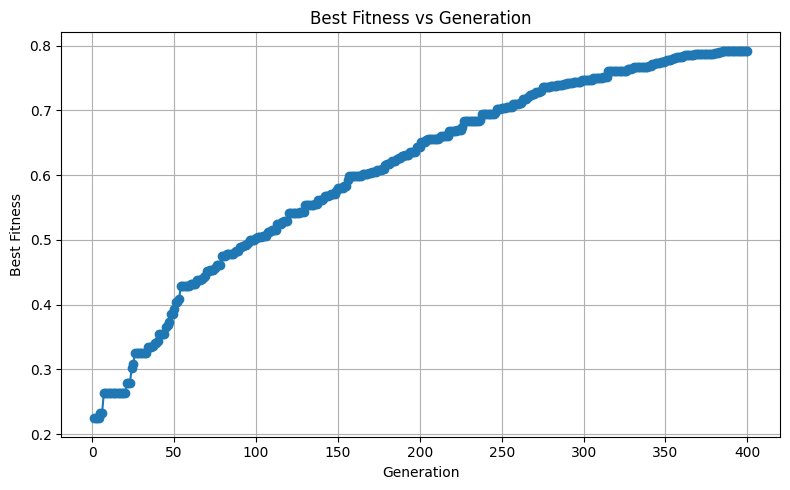

In [20]:
# --- 10. Fitness vs Generation
plt.figure(figsize=(8, 5))
plt.plot(range(1, GENERATIONS + 1), fitness_history, marker='o')
plt.title("Best Fitness vs Generation")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
with open("best_weights.pkl", "wb") as f:
    pkl.dump(best, f)
# print("Best weights saved to best_weights.npy")

In [21]:
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
               'Pasture', 'PermanentCrop', 'Residential', 'SeaLake']


Test accuracy of best evolved model: 0.7804


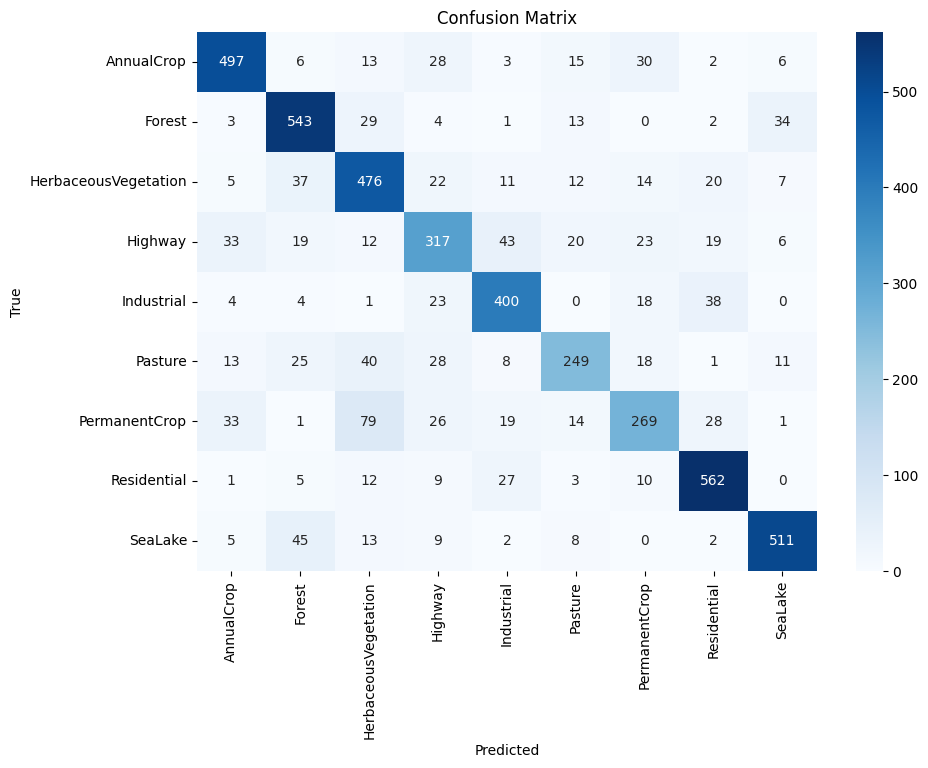

In [22]:

# Final Evaluation
best = population[np.argmax([fitness(ind) for ind in population])]
y_pred_test = predict(best, X_test)

# Calculate test accuracy
test_acc = np.mean(np.argmax(y_pred_test, axis=1) == np.argmax(y_test_cat, axis=1))
print(f"\nTest accuracy of best evolved model: {test_acc:.4f}")

# Confusion matrix
y_true = np.argmax(y_test_cat, axis=1)
y_pred = np.argmax(y_pred_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
